In [1]:
import pandas as pd
import numpy as np
import rasterio as rio
import rasterio.plot
import sklearn
import sklearn.linear_model
import sklearn.svm
import geopandas as gpd

import matplotlib.pyplot as plt


In [2]:
predicts_coords = pd.read_csv('../data/01_raw/PREDICTs_coords.csv')
predicts_coords.set_index('SSBS', inplace=True)
predicts_coords.head()

,Unnamed: 0,SSB,MaxAbundance,TotalAbundance,RescaledAbundance,Sample_midpoint,Latitude,Longitude,Study_common_taxon,Predominant_land_use,Max_linear_extent_metres
SSBS,,,,,,,,,,,
AD1_2001__Liow 1 1,1,AD1_2001__Liow 1,242.0,42.0,0.173554,1999-05-01,1.351944,103.778611,Apidae,Primary vegetation,3000.0
AD1_2001__Liow 1 2,2,AD1_2001__Liow 1,242.0,242.0,1.000000,1999-04-25,1.354722,103.808056,Apidae,Mature secondary vegetation,3000.0
AD1_2001__Liow 1 3,3,AD1_2001__Liow 1,242.0,232.0,0.958678,1999-05-12,1.394722,103.811667,Apidae,Mature secondary vegetation,3000.0
AD1_2001__Liow 1 4,4,AD1_2001__Liow 1,242.0,185.0,0.764463,1999-06-16,1.326944,103.787222,Apidae,Intermediate secondary vegetation,1800.0
AD1_2001__Liow 1 5,5,AD1_2001__Liow 1,242.0,94.5,0.390496,1999-05-02,1.282778,103.803611,Apidae,Intermediate secondary vegetation,2000.0


In [3]:
encoded_tiles = pd.read_parquet('../data/03_primary/s2_encoded_chips.parquet')
print(len(encoded_tiles))
encoded_tiles = encoded_tiles.dropna()
encoded_tiles

1567


,0,1,2,3,4,5,6,7,8,9,...,758,759,760,761,762,763,764,765,766,767
AD1_2005__Shuler 1 1,-0.023824,-0.046564,-0.121890,0.045702,0.066044,0.107647,-0.206686,0.080760,-0.036886,0.043008,...,0.153034,-0.012189,0.083502,0.070904,-0.052851,0.046444,0.015274,0.033927,0.157787,0.132819
AD1_2005__Shuler 1 10,0.031736,-0.102439,-0.111340,0.042668,0.103696,0.382737,-0.121367,0.083632,-0.077313,0.043660,...,0.071266,0.076916,-0.004073,0.056833,0.001932,0.066771,-0.043067,0.036507,0.166643,0.091563
AD1_2005__Shuler 1 11,0.038374,-0.043365,-0.096734,0.064969,0.078917,0.133522,-0.154009,0.173428,-0.004819,-0.013063,...,0.057633,0.248954,-0.051272,0.056564,-0.012945,0.043327,0.021416,-0.014968,0.195732,0.185999
AD1_2005__Shuler 1 12,-0.019436,-0.041390,-0.112176,0.035251,0.066881,0.209681,-0.172266,0.181483,-0.038888,0.040880,...,0.121121,0.188689,0.010247,0.016133,-0.066379,0.074851,0.003199,-0.030890,0.162227,0.171826
AD1_2005__Shuler 1 13,-0.050793,0.039764,-0.107740,0.023600,0.196930,0.202264,-0.069656,0.053940,-0.141824,0.057538,...,-0.005245,0.142056,-0.011672,0.058776,-0.014598,0.023709,-0.091708,0.036591,0.089808,0.038451
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
VK1_2011__Zimmerman 1 4 11,0.073134,-0.096427,-0.067157,0.015114,0.115528,-0.185659,-0.065817,0.199339,-0.054246,-0.004339,...,0.207385,0.308973,0.028570,0.088776,-0.081135,0.047464,0.023068,0.041792,-0.017390,0.153260
VK1_2011__Zimmerman 1 4 12,0.085462,-0.085444,-0.050283,0.020911,0.101309,-0.162645,-0.075602,0.176812,-0.040522,-0.014088,...,0.226639,0.327861,0.030160,0.080935,-0.086663,0.060446,0.012394,0.034245,-0.015255,0.151531
VK1_2011__Zimmerman 1 4 13,0.054963,-0.073036,-0.065483,0.013907,0.074991,-0.133479,-0.074853,0.145629,-0.040090,0.017675,...,0.267347,0.372403,0.024031,0.072725,-0.073235,0.060138,0.010383,0.028955,-0.023273,0.130447
VK1_2011__Zimmerman 1 4 14,0.056863,-0.072988,-0.041342,0.015471,0.118352,-0.190948,-0.077384,0.189664,-0.066763,0.016944,...,0.196291,0.326381,0.014338,0.092059,-0.080822,0.050742,0.021041,0.041556,-0.045326,0.147632


In [4]:
predicts_data = pd.read_parquet('../data/01_raw/PREDICTs_pairs_with_abundance.parquet')
predicts_data.s1 = predicts_data.s1.str.replace('/', '_')
predicts_data.s2 = predicts_data.s2.str.replace('/', '_')
predicts_data.head()

predicted_bii = pd.read_csv('../data/01_raw/predicted_values.csv')
predicted_bii = predicted_bii.filter(["UniqueID", "bii", 'abundance', 'community_similarity']).set_index('UniqueID')
predicts_data = predicts_data.join(predicted_bii, on=['s2'])
predicts_data.head()


,s1,s2,contrast,SS,bray,s1_lat,s1_long,s2_lat,s2_long,geog_dist,s1_lu,s2_lu,lu_contrast,s1_TotalAbundance,s2_TotalAbundance,s2_relative_abundance,bii,abundance,community_similarity
0,AD1_2006__McFrederick 1 17,AD1_2006__McFrederick 1 1,AD1_2006__McFrederick 1 17_vs_AD1_2006__McFre...,AD1_2006__McFrederick 1,0.914894,37.691700,-122.433556,37.715000,-122.393056,4410.346336,Primary minimal,Urban,Primary minimal_vs_Urban,47.0,114.0,2.425532,0.438427,0.929259,0.471803
1,AD1_2006__McFrederick 1 18,AD1_2006__McFrederick 1 1,AD1_2006__McFrederick 1 18_vs_AD1_2006__McFre...,AD1_2006__McFrederick 1,1.000000,37.618219,-122.461981,37.715000,-122.393056,12367.647418,Primary minimal,Urban,Primary minimal_vs_Urban,56.0,114.0,2.035714,0.438427,0.929259,0.471803
2,AD1_2006__McFrederick 1 17,AD1_2006__McFrederick 1 2,AD1_2006__McFrederick 1 17_vs_AD1_2006__McFre...,AD1_2006__McFrederick 1,0.936170,37.691700,-122.433556,37.743056,-122.413889,5973.480700,Primary minimal,Primary vegetation,Primary minimal_vs_Primary vegetation,47.0,162.0,3.446809,0.355775,0.777370,0.457665
3,AD1_2006__McFrederick 1 18,AD1_2006__McFrederick 1 2,AD1_2006__McFrederick 1 18_vs_AD1_2006__McFre...,AD1_2006__McFrederick 1,1.000000,37.618219,-122.461981,37.743056,-122.413889,14528.344901,Primary minimal,Primary vegetation,Primary minimal_vs_Primary vegetation,56.0,162.0,2.892857,0.355775,0.777370,0.457665
4,AD1_2006__McFrederick 1 17,AD1_2006__McFrederick 1 3,AD1_2006__McFrederick 1 17_vs_AD1_2006__McFre...,AD1_2006__McFrederick 1,0.936170,37.691700,-122.433556,37.717222,-122.466667,4071.365839,Primary minimal,Urban,Primary minimal_vs_Urban,47.0,94.0,2.000000,0.361292,0.782426,0.461758


<Axes: >

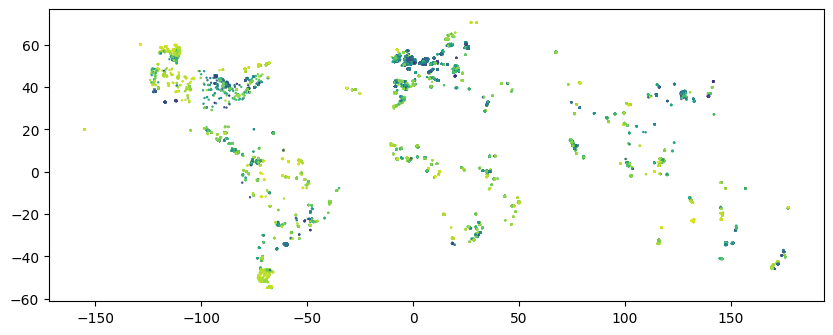

In [5]:
from matplotlib import markers


predicts_coords.index = predicts_coords.index.str.replace('/', '_')
df = predicts_coords.join(predicted_bii)
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.Longitude, df.Latitude))
gdf.plot(column='bii', cmap='viridis', figsize=(10, 10), markersize=.5)

In [6]:
np.random.seed(20240910)

all_data = predicts_data
all_data = all_data.join(predicts_coords['RescaledAbundance'], on='s2')
weights = all_data.groupby('s2').transform("size") * all_data.groupby('s1').transform("size")
all_data['weights'] = 1/weights
all_data['bray_adj'] = all_data['bray'] - all_data.groupby('s1')['bray'].transform('mean')
all_data['ln_relative_abundance'] = np.log(all_data['s2_relative_abundance'].clip(0.01, 100))
all_data['ln_relative_abundance'] = all_data['ln_relative_abundance'] - all_data.groupby('s1')['ln_relative_abundance'].transform('mean')
all_data.dropna(inplace=True)


filtered_data = all_data.where(predicts_data.s1.isin(encoded_tiles.index) & predicts_data.s2.isin(encoded_tiles.index)).dropna().reset_index(drop=True)
encodings_data = encoded_tiles.loc[filtered_data.s2].set_index(filtered_data.index)

In [7]:
from sklearn.model_selection import GroupKFold, ValidationCurveDisplay
from sklearn.linear_model import Ridge
from sklearn.metrics import explained_variance_score
alphas = np.logspace(-4, 3, 9)

def score(model, X, y, weights):
    return explained_variance_score(y, model.predict(X), sample_weight=weights)

def weighted_val_curve(Model, X, y, weights, alphas, groups, kw='alpha', **kwargs):
    train_scores = []
    test_scores = []
    gkf = GroupKFold(n_splits=5)
    for alpha in alphas:
        _train = []
        _test = []
        for train_idx, test_idx in gkf.split(X, y, groups=groups):
            model = Model(**{kw:alpha})
            model.fit(X.iloc[train_idx], y.iloc[train_idx], sample_weight=weights.iloc[train_idx])
            _train.append(score(model, X.iloc[train_idx], y.iloc[train_idx], weights.iloc[train_idx]))
            _test.append(score(model, X.iloc[test_idx], y.iloc[test_idx], weights.iloc[test_idx]))
        train_scores.append(_train)
        test_scores.append(_test)
    train_scores = np.array(train_scores)
    test_scores = np.array(test_scores)
    ValidationCurveDisplay(param_name="alpha", param_range=alphas, train_scores=train_scores, test_scores=test_scores, score_name="Explained variance").plot(**kwargs)


Clay embeddings on s2 imagery


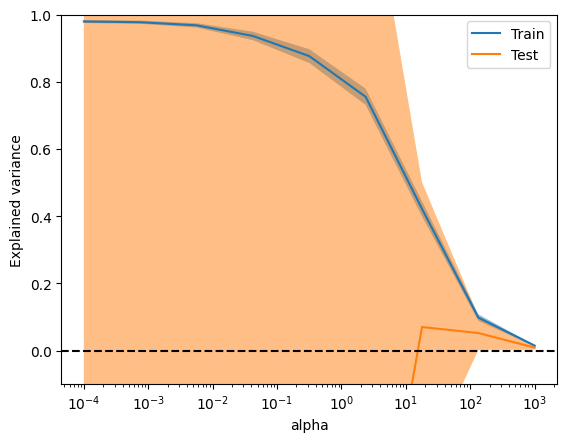

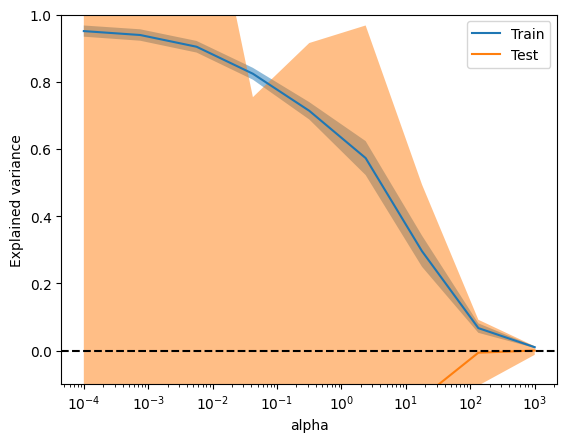

19783


In [8]:


print("Clay embeddings on s2 imagery")
ax = plt.subplot()
weighted_val_curve(Ridge, encodings_data, filtered_data.community_similarity, filtered_data.weights, alphas, filtered_data.SS, ax=ax)
plt.axhline(0, color='black', linestyle='--')
ax.set_ylim(-.1, 1)
plt.show()
ax = plt.subplot()
weighted_val_curve(Ridge, encodings_data, filtered_data.abundance, filtered_data.weights, alphas, filtered_data.SS, ax=ax)
plt.axhline(0, color='black', linestyle='--')
ax.set_ylim(-.1, 1)
plt.show()

print(len(encodings_data))

LAND USE ONLY


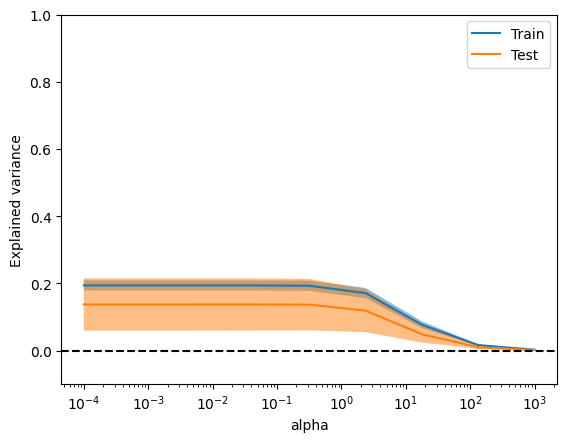

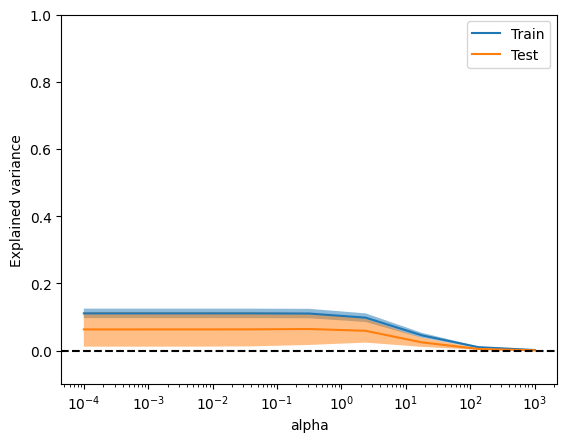

{'Cropland': -0.14132731308427357,
 'Pasture': -0.05901581960957716,
 'Plantation forest': -0.04434688639118683,
 'Primary vegetation': -0.015530040733081075,
 'Secondary vegetation': -0.01149309320316371,
 'Urban': -0.32456334582040436}
{'Cropland': -0.006525921425295292,
 'Pasture': 0.008345374792634109,
 'Plantation forest': -0.016440606165307008,
 'Primary vegetation': -0.011956284275704488,
 'Secondary vegetation': -0.0027768249805926915,
 'Urban': -0.09719966113096287}
574030


In [9]:
from pprint import pprint
print("LAND USE ONLY")
data = all_data
dummyvars = pd.get_dummies(data.s2_lu, drop_first=True)

ax = plt.subplot()
weighted_val_curve(Ridge, dummyvars, data.community_similarity, data.weights, alphas, data.SS, ax=ax)
plt.axhline(0, color='black', linestyle='--')
ax.set_ylim(-.1, 1)
plt.show()
ax = plt.subplot()
weighted_val_curve(Ridge, dummyvars, data.abundance, data.weights, alphas, data.SS, ax=ax)
plt.axhline(0, color='black', linestyle='--')
ax.set_ylim(-.1, 1)
plt.show()

mdl = Ridge(alpha=1)
mdl.fit(dummyvars, data.community_similarity, sample_weight=data.weights)
pprint(dict(zip(dummyvars.columns, mdl.coef_)))

mdl = Ridge(alpha=1)
mdl.fit(dummyvars, data.abundance, sample_weight=data.weights)
pprint(dict(zip(dummyvars.columns, mdl.coef_)))

print(len(all_data))

In [ ]:

bray_model = sklearn.linear_model.Ridge(alpha=10)
#bray_model = sklearn.svm.SVR()
bray_model.fit(encodings_data, filtered_data.community_similarity, sample_weight=filtered_data.weights)

ab_model = sklearn.linear_model.Ridge(alpha=10) 
#ab_model = sklearn.svm.SVR()
ab_model.fit(encodings_data, filtered_data.abundance, sample_weight=filtered_data.weights)

Ridge(alpha=10)

<Axes: xlabel='0', ylabel='1'>

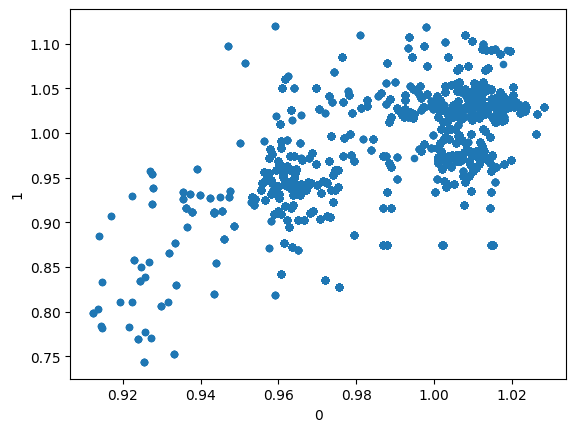

In [45]:
pd.DataFrame([ab_model.predict(encodings_data), filtered_data.abundance]).T.plot(kind='scatter', x=0, y=1)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.01..1.1728].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0004..1.5888].


HW1_2007__Chapman 1 2 61_vs_HW1_2007__Chapman 1 8 268
Site embedding similarity (corr): 0.8767392810205916

Site 1 Primary vegetation, extent 200.0, taxon Aves 	Site 2 Primary vegetation, extent 200.0, taxon Aves
Site 1 coords 45.39433, -93.1855		Site 2 coords 45.07033, -93.10183
Nat comp. predicted: 0.7053565979003906,	actual: 0.8052419889189657		Nat comp. predicted: 0.6104739308357239,	actual: 0.5855288016706777
Abundance predicted: 1.0096954107284546,	actual: 1.0266971817997945		Abundance predicted: 0.9734054207801819,	actual: 0.9961511789637271


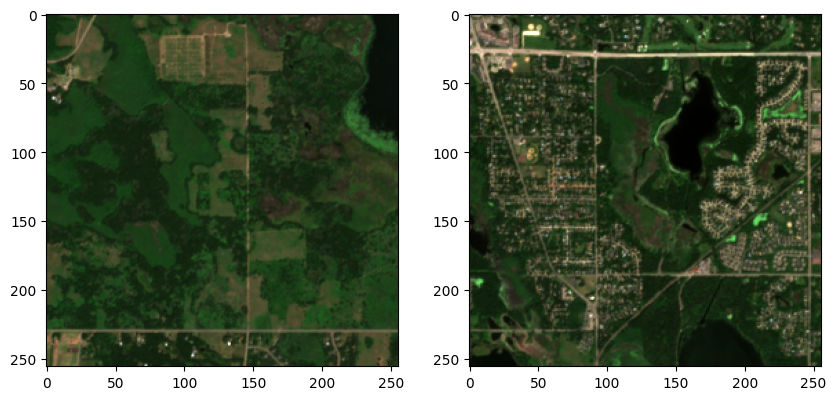

Actual difference:    Abundance: 🔻-0.031, Nat comp: 🔻-0.220
Predicted difference: Abundance: 🔻-0.036, Nat comp: 🔻-0.095


In [50]:

def _emoji(x):
    if x < -0.01:
        return f'🔻{x:.3f}'
    if x > 0.01:
        return f'🌲{x:.3f}'
    return f'🟡{x:.3f}'

def test_hold_idx(row):
    s1 = encoded_tiles.loc[row.s1]
    s2 = encoded_tiles.loc[row.s2]
    print(f"Site embedding similarity (corr): {np.corrcoef(s1, s2)[0, 1]}\n")
    s1meta = predicts_coords.loc[row.s1]
    s2meta = predicts_coords.loc[row.s2]

    a_bray1 = filtered_data[filtered_data.s2 == row.s1].community_similarity.mean()
    a_abund1 = filtered_data[filtered_data.s2 == row.s1].abundance.mean()
    a_bray2 = filtered_data[filtered_data.s2 == row.s2].community_similarity.mean()
    a_abund2 = filtered_data[filtered_data.s2 == row.s2].abundance.mean()

    p_bray1 = bray_model.predict(s1.values.reshape(1, -1))[0]
    p_abund1 = ab_model.predict(s1.values.reshape(1, -1))[0]
    p_bray2 = bray_model.predict(s2.values.reshape(1, -1))[0]
    p_abund2 = ab_model.predict(s2.values.reshape(1, -1))[0]

    print(f"Site 1 {s1meta.Predominant_land_use}, extent {s1meta.Max_linear_extent_metres}, taxon {s1meta.Study_common_taxon} " \
          f"\tSite 2 {s2meta.Predominant_land_use}, extent {s2meta.Max_linear_extent_metres}, taxon {s2meta.Study_common_taxon}")
    print(f"Site 1 coords {s1meta.Latitude}, {s1meta.Longitude}" \
          f"\t\tSite 2 coords {s2meta.Latitude}, {s2meta.Longitude}")
    print(f"Nat comp. predicted: {p_bray1},\tactual: {a_bray1}\t\tNat comp. predicted: {p_bray2},\tactual: {a_bray2}")
    print(f"Abundance predicted: {p_abund1},\tactual: {a_abund1}\t\tAbundance predicted: {p_abund2},\tactual: {a_abund2}")
    fig, axs = plt.subplots(1, 2, figsize=(10, 5))
    with rio.open(f'../data/02_intermediate/s2_stacks_filtered/{row.s1}.tif') as src:
        rio.plot.show(src.read([3, 2, 1])/2500, ax=axs[0])
    with rio.open(f'../data/02_intermediate/s2_stacks_filtered/{row.s2}.tif') as src:
        rio.plot.show(src.read([3, 2, 1])/2500, ax=axs[1])
    plt.show()

    a_bray_change = _emoji(a_bray2 - a_bray1)
    p_bray_change = _emoji(p_bray2 - p_bray1)
    a_abund_change = _emoji(a_abund2 - a_abund1)
    p_abund_change = _emoji(p_abund2 - p_abund1)
    print(f"Actual difference:    Abundance: {a_abund_change}, Nat comp: {a_bray_change}")
    print(f"Predicted difference: Abundance: {p_abund_change}, Nat comp: {p_bray_change}")

row = filtered_data.loc[np.random.randint(0, len(filtered_data))]
print(row.contrast)
test_hold_idx(row)